# CTM repetition-counting visualisations

Run after training (or after a few hundred synthetic iterations). Point `CKPT_DIR` at a
training log directory; the notebook loads the checkpoint, runs one clip through the model
with `track=True`, and produces the following plots:

1. **Clip preview** — sampled frames grid.
2. **Certainty over ticks** — with GT count annotated.
3. **Per-tick count prediction** — argmax and expected-value count converging over ticks.
4. **Neuron raster** — D neurons × ticks, sorted by dominant FFT frequency.
5. **Attention overlay** — per-frame spatial attention heatmap.
6. **UMAP trajectory** — output-synchronisation vector across ticks.
7. **Per-neuron FFT** — do different neurons lock to different temporal frequencies?
8. **FFT-based count decoder** — unsupervised count estimate from peak neuron oscillation frequency. This is the core interpretability result: if the PLL hypothesis holds, the FFT-decoded count should match the ground-truth count without any direct supervision on frequencies.
9. **Synchronisation magnitude** — action and output sync accumulators over time.

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
# Allow running from tasks/repetition/analysis/ with repo root on path.
#REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
REPO_ROOT = "/users/ghermi/code/continuous-thought-machines"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print('cwd:', os.getcwd())

cwd: /home/ghermi/code/continuous-thought-machines


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from tasks.repetition.model import ContinuousThoughtMachineRepCount
from tasks.repetition.dataset import build_datasets
from tasks.repetition.utils import count_from_buckets

CKPT_DIR = 'logs_jz/repetition/synthetic'   # <- edit me
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


In [4]:
ckpt = torch.load(f'{CKPT_DIR}/checkpoint.pt', map_location=DEVICE, weights_only=False)
args = ckpt['args']

_, test_data = build_datasets(
    args.dataset, args.data_root, args.n_frames, args.image_size,
    max_count=getattr(args, 'max_count', 16),
)

model = ContinuousThoughtMachineRepCount(
    n_frames=args.n_frames,
    iterations_per_frame=args.iterations_per_frame,
    d_model=args.d_model, d_input=args.d_input, heads=args.heads,
    n_synch_out=args.n_synch_out, n_synch_action=args.n_synch_action,
    synapse_depth=args.synapse_depth, memory_length=args.memory_length,
    deep_nlms=args.deep_memory, memory_hidden_dims=args.memory_hidden_dims,
    do_layernorm_nlm=args.do_normalisation,
    backbone_type=args.backbone_type,
    pretrained_backbone=getattr(args, 'pretrained_backbone', False),
    freeze_backbone=getattr(args, 'freeze_backbone', False),
    positional_embedding_type=args.positional_embedding_type,
    out_dims=args.out_dims, prediction_reshaper=[-1],
    dropout=0.0, neuron_select_type=args.neuron_select_type,
).to(DEVICE)

# Initialise lazy modules, then load weights.
dummy, _ = test_data[0]
model(dummy.unsqueeze(0).to(DEVICE))
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded checkpoint from iteration {ckpt["iteration"]}  |  '
      f'n_frames={args.n_frames}  buckets={args.out_dims}')

Using neuron select type: random-pairing
Synch representation size action: 64
Synch representation size out: 64
Loaded checkpoint from iteration 5000  |  n_frames=64  buckets=32


In [5]:
# Pick a clip and run forward with tracking on.
CLIP_INDEX = 2
clip, gt_count = test_data[CLIP_INDEX]
gt_count = int(gt_count)
clip_t = clip.unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    (predictions, certainties, synch_tracks,
     pre_acts, post_acts, attention, frame_idx_track, kv_shape) = model(clip_t, track=True)

predictions = predictions.cpu().numpy()[0]          # (n_buckets, ticks)
certainties = certainties.cpu().numpy()[0]          # (2, ticks)
synch_out_track, synch_action_track = synch_tracks  # (ticks, 1, S)
post_acts = post_acts[:, 0]                         # (ticks, D)
attention  = attention[:, 0]                        # (ticks, heads, 1, tokens)

n_ticks = predictions.shape[1]
n_buckets = predictions.shape[0]

# Decode predictions at every tick.
preds_t = torch.from_numpy(predictions.T)           # (ticks, n_buckets)
expected_counts, argmax_counts = count_from_buckets(preds_t)
expected_counts = expected_counts.numpy()
argmax_counts   = argmax_counts.numpy()

mc_tick = int(certainties[1].argmax())
mc_argmax = int(argmax_counts[mc_tick])
mc_expected = float(expected_counts[mc_tick])

print(f'GT count           : {gt_count}')
print(f'Argmax at MC tick  : {mc_argmax}  (tick {mc_tick})')
print(f'Expected at MC tick: {mc_expected:.2f}')
print(f'attention shape    : {attention.shape}  kv_shape: {kv_shape}')

GT count           : 12
Argmax at MC tick  : 12  (tick 53)
Expected at MC tick: 12.00
attention shape    : (64, 4, 1, 256)  kv_shape: (16, 16)


## 1. Clip preview

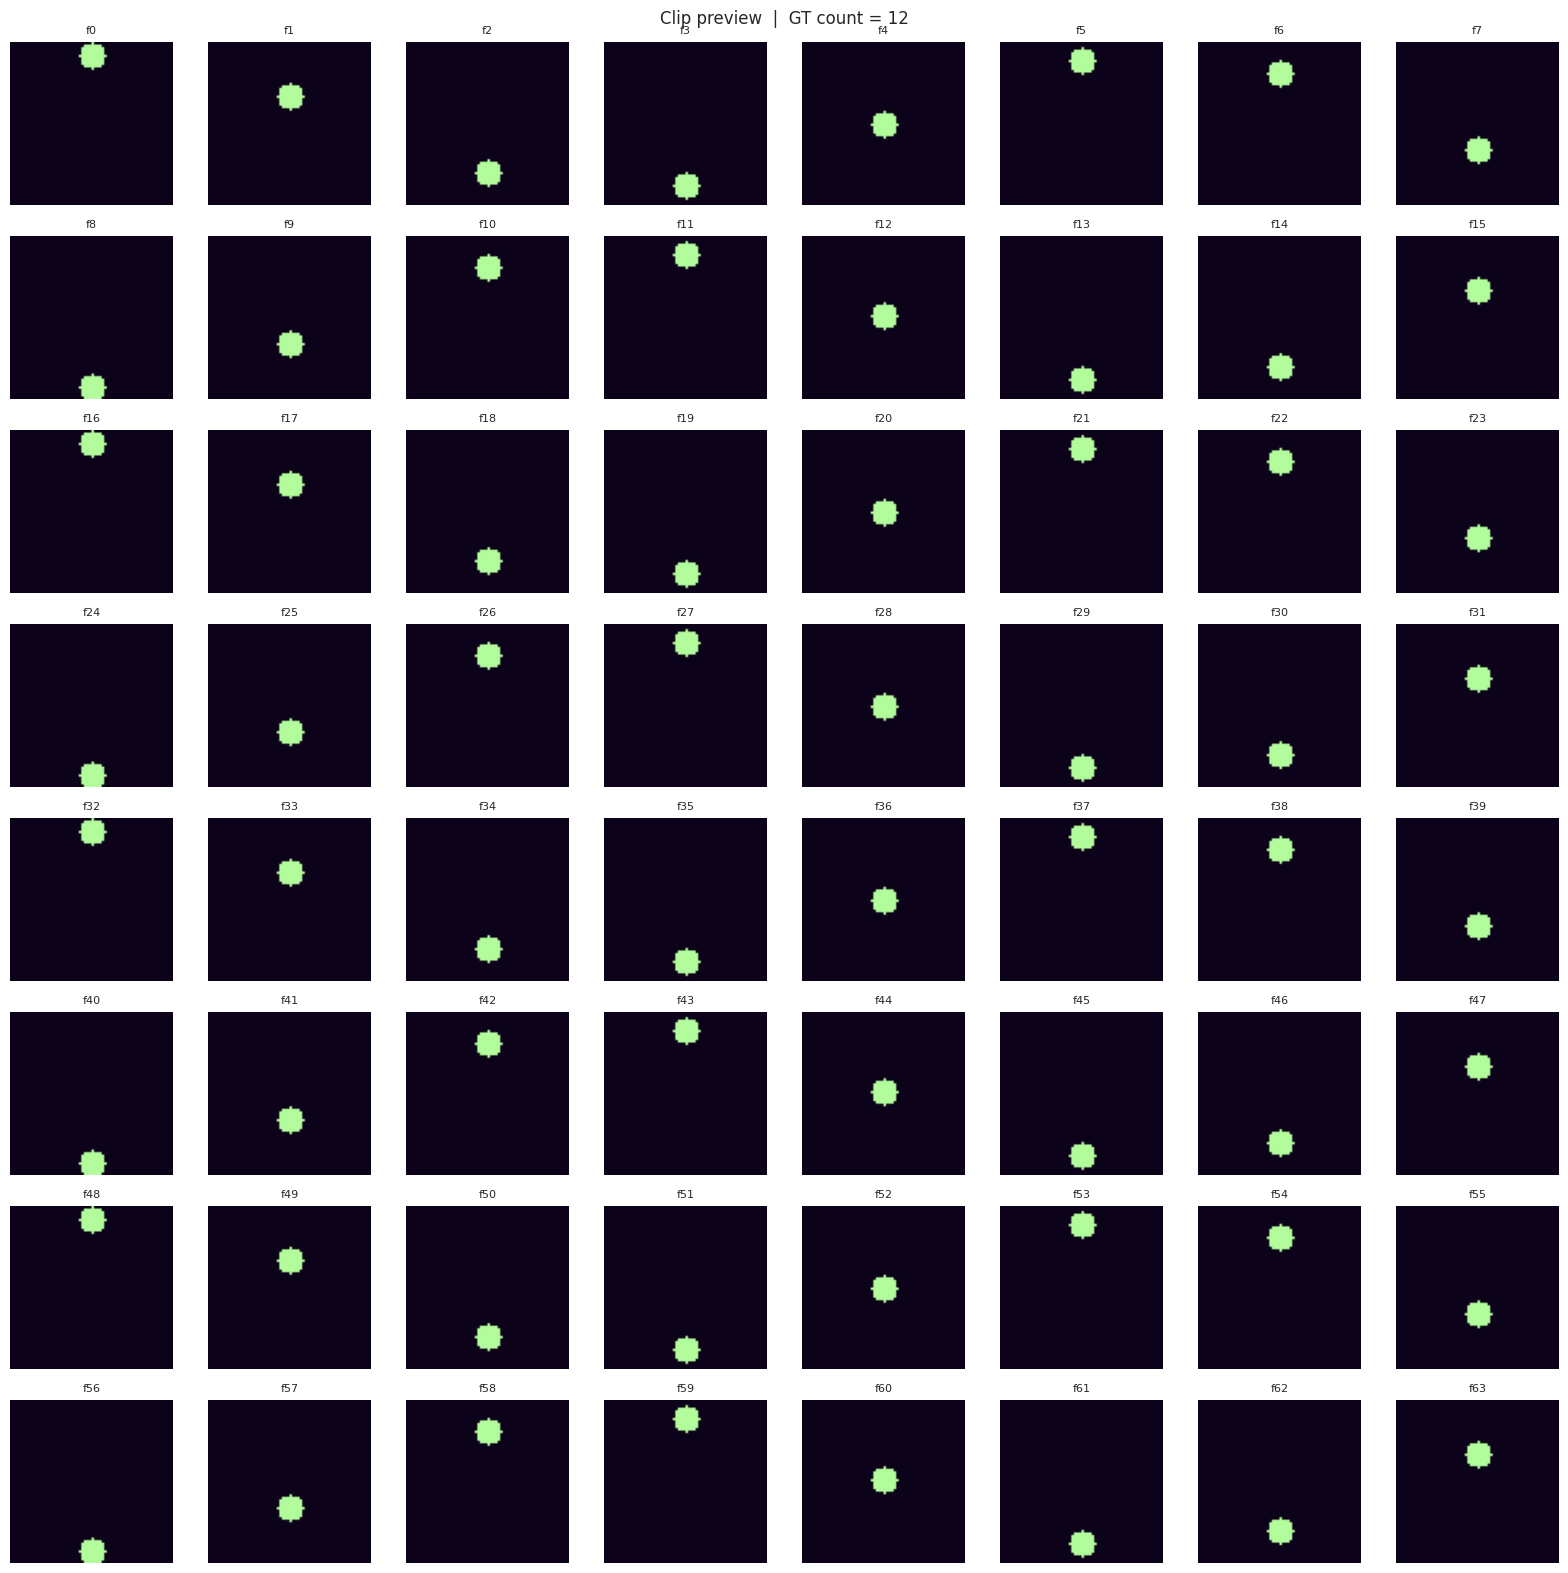

In [6]:
def denorm(clip_np):
    """Undo per-dataset normalisation for display."""
    if args.dataset == 'synthetic':
        return np.clip(clip_np * 0.5 + 0.5, 0, 1)
    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)
    return np.clip(clip_np * std + mean, 0, 1)

clip_np = denorm(clip.numpy())  # (T, 3, H, W)
T = clip_np.shape[0]
cols = min(8, T); rows = int(np.ceil(T / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(rows, cols)
for i in range(rows * cols):
    ax = axes[i // cols, i % cols]; ax.axis('off')
    if i < T:
        ax.imshow(np.moveaxis(clip_np[i], 0, -1))
        ax.set_title(f'f{i}', fontsize=8)
fig.suptitle(f'Clip preview  |  GT count = {gt_count}', fontsize=12)
fig.tight_layout(); plt.show()

## 2. Certainty over ticks

`certainties[1]` is `1 - normalised_entropy(predictions_t)`. Green spans mark ticks where
the argmax count equals the GT count; red spans mark wrong ticks.

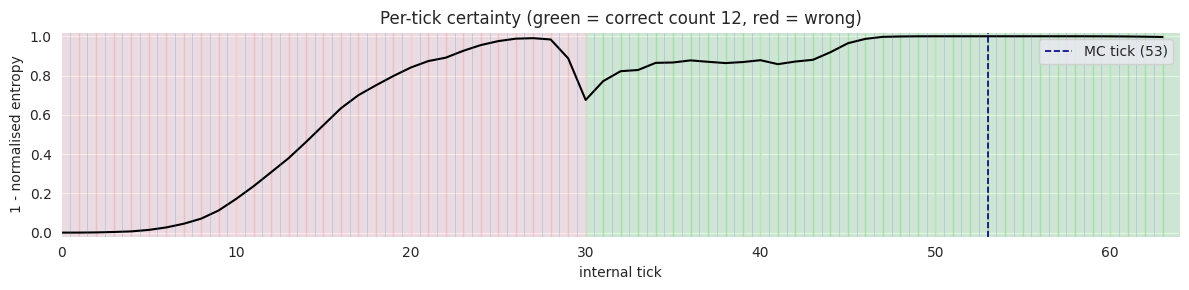

In [7]:
ticks = np.arange(n_ticks)
is_correct = (argmax_counts == gt_count)
fig, ax = plt.subplots(figsize=(12, 3))
for t in ticks:
    ax.axvspan(t, t + 1, color='limegreen' if is_correct[t] else 'lightcoral', alpha=0.15)
ax.plot(ticks, certainties[1], 'k-', lw=1.5)
ax.axvline(mc_tick, color='navy', lw=1.2, ls='--', label=f'MC tick ({mc_tick})')
for b in range(0, n_ticks, args.iterations_per_frame):
    ax.axvline(b - 0.5, color='steelblue', lw=0.4, alpha=0.4)
ax.set_ylim(-0.02, 1.02); ax.set_xlim(0, n_ticks)
ax.set_xlabel('internal tick'); ax.set_ylabel('1 - normalised entropy')
ax.set_title(f'Per-tick certainty (green = correct count {gt_count}, red = wrong)')
ax.legend(); fig.tight_layout(); plt.show()

## 3. Per-tick count prediction

Both the hard argmax and the soft expected-value count across ticks. A well-trained
model should converge to the GT count (dashed green) and hold it.

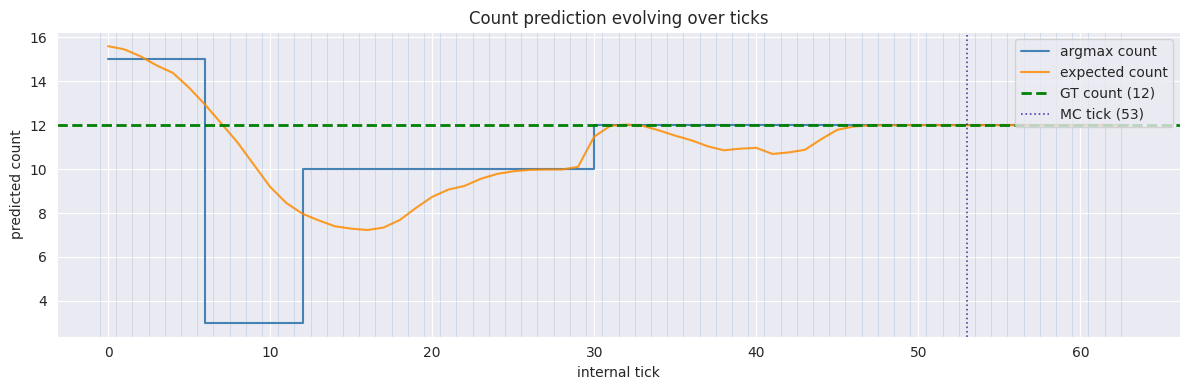

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.step(ticks, argmax_counts, 'steelblue', where='post', lw=1.5, label='argmax count')
ax.plot(ticks, expected_counts, color='darkorange', lw=1.5, alpha=0.85, label='expected count')
ax.axhline(gt_count, color='green', ls='--', lw=2, label=f'GT count ({gt_count})')
ax.axvline(mc_tick, color='navy', lw=1.2, ls=':', alpha=0.7, label=f'MC tick ({mc_tick})')
for b in range(0, n_ticks, args.iterations_per_frame):
    ax.axvline(b - 0.5, color='steelblue', lw=0.4, alpha=0.3)
ax.set_xlabel('internal tick'); ax.set_ylabel('predicted count')
ax.set_title('Count prediction evolving over ticks')
ax.legend(loc='upper right'); fig.tight_layout(); plt.show()

## 4. Neuron raster

Rows = a subset of CTM neurons, columns = ticks. Neurons are sorted by
dominant FFT frequency — expect visible horizontal banding: low-frequency
oscillators at the top, high-frequency at the bottom.

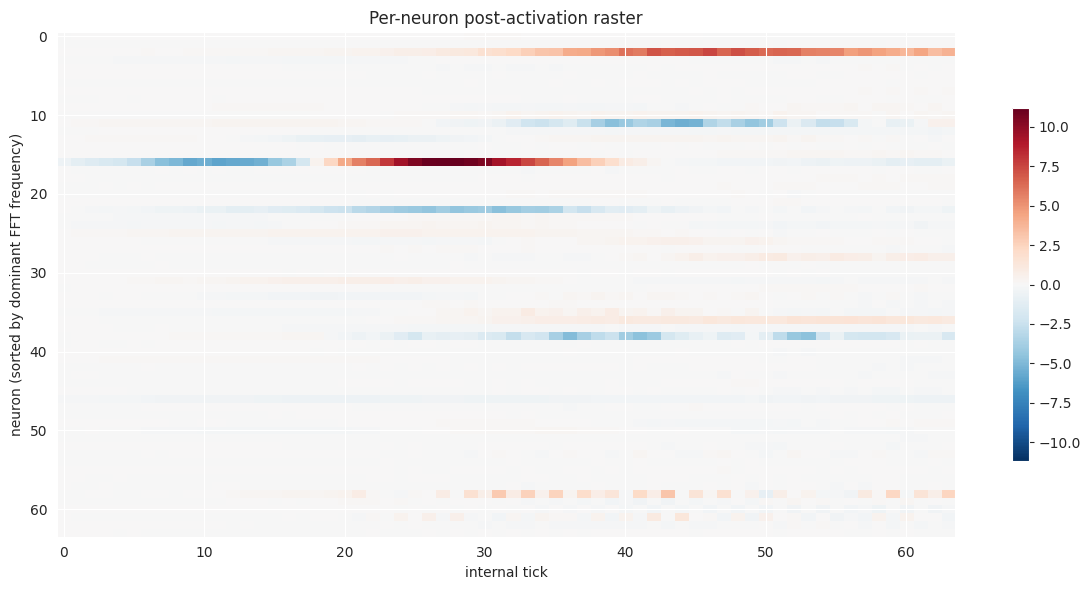

In [12]:
N_NEURONS = 64
fft_mag = np.abs(np.fft.rfft(post_acts, axis=0))[1:]   # skip DC; (n_freqs, D)
peak_freq = fft_mag.argmax(axis=0)
order = np.argsort(peak_freq)
chosen = order[np.linspace(0, len(order) - 1, N_NEURONS).astype(int)]
raster = post_acts[:, chosen].T  # (N_NEURONS, ticks)

fig, ax = plt.subplots(figsize=(12, 6))
lim = np.abs(raster).max()
im = ax.imshow(raster, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim,
               interpolation='nearest')
ax.set_xlabel('internal tick')
ax.set_ylabel('neuron (sorted by dominant FFT frequency)')
ax.set_title('Per-neuron post-activation raster')
plt.colorbar(im, ax=ax, shrink=0.7); fig.tight_layout(); plt.show()

## 5. Attention overlay per frame

Cross-attention weights at each tick reshaped back to the spatial grid and
overlaid on the corresponding frame.

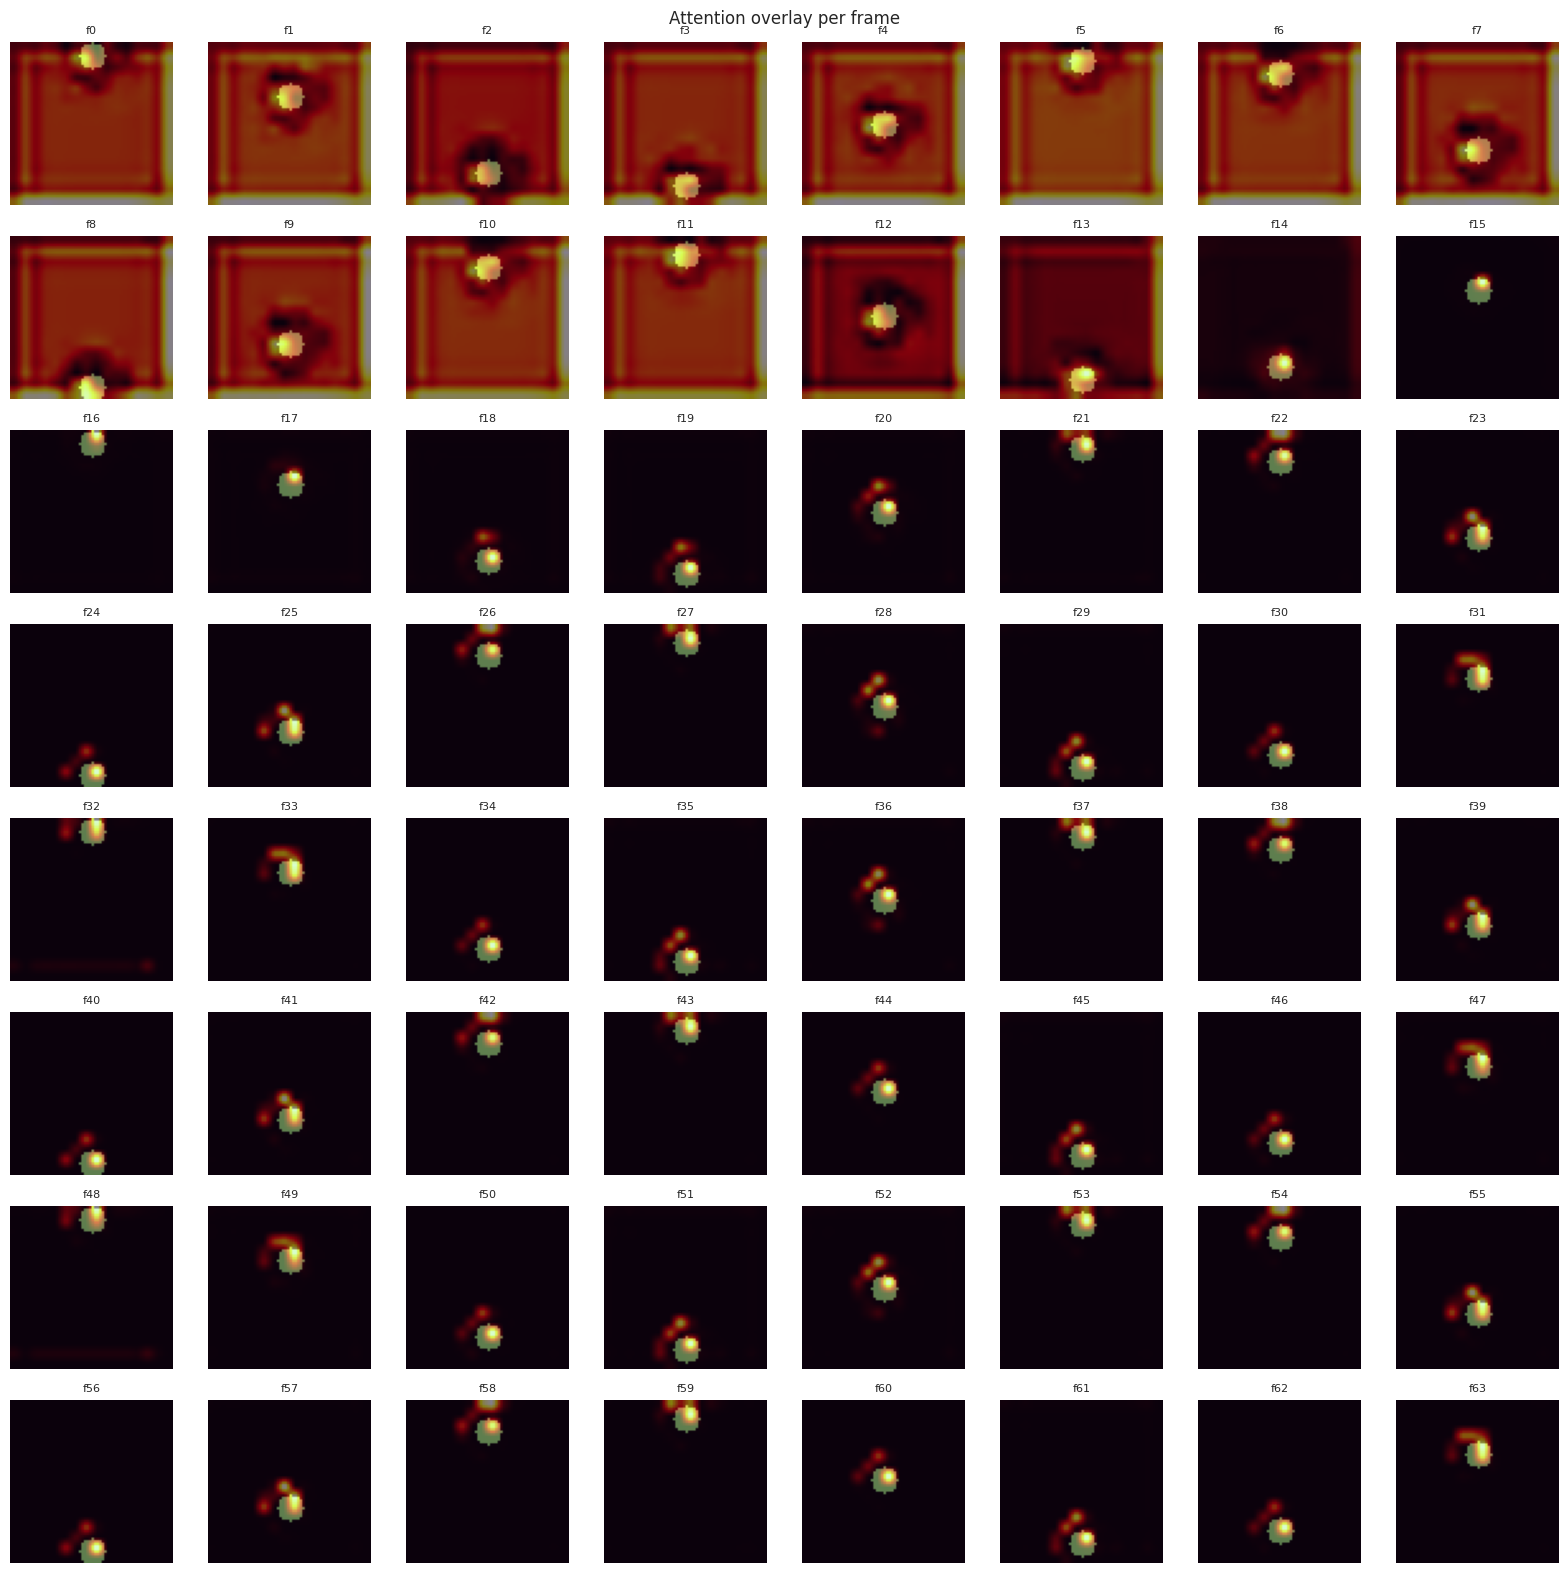

In [13]:
import torch.nn.functional as F

Hp, Wp = kv_shape
# attention: (ticks, heads, 1, Hp*Wp). Mean over heads, drop singleton query dim.
attn = attention.mean(axis=1)                           # (ticks, 1, Hp*Wp)
attn = attn.reshape(attn.shape[0], 1, Hp, Wp)
attn_tensor = torch.from_numpy(attn).float()
H, W = clip_np.shape[2], clip_np.shape[3]
attn_up = F.interpolate(
    attn_tensor, size=(H, W), mode='bilinear', align_corners=False
).squeeze(1).numpy()                                    # (ticks, H, W)

K = args.iterations_per_frame
per_frame_attn = np.stack(
    [attn_up[f * K:(f + 1) * K].mean(0) for f in range(T)], axis=0
)

cols = min(8, T); rows = int(np.ceil(T / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(rows, cols)
for i in range(rows * cols):
    ax = axes[i // cols, i % cols]; ax.axis('off')
    if i < T:
        ax.imshow(np.moveaxis(clip_np[i], 0, -1))
        a = per_frame_attn[i]
        a = (a - a.min()) / (a.max() - a.min() + 1e-9)
        ax.imshow(a, cmap='hot', alpha=0.5)
        ax.set_title(f'f{i}', fontsize=8)
fig.suptitle('Attention overlay per frame', fontsize=12)
fig.tight_layout(); plt.show()

## 6. UMAP of the output-synchronisation vector

Trajectory of the latent representation (sync vector) across ticks. For a
periodic video, expect a circular or looping path whose winding number equals
the repetition count.

/users/ghermi/miniconda3/envs/ctm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


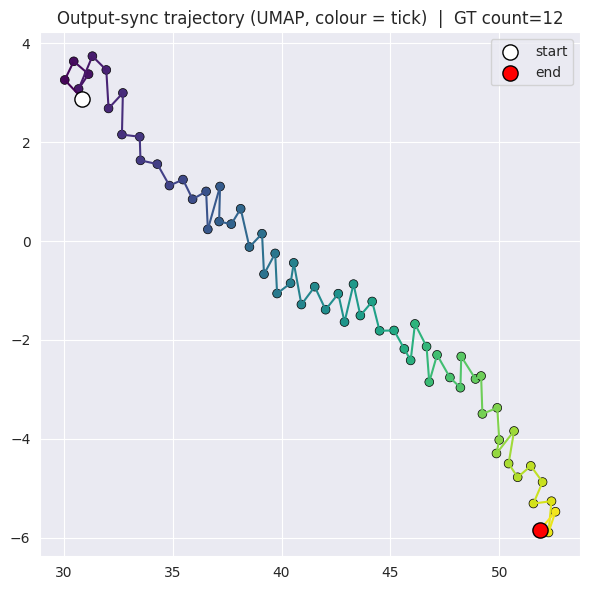

In [14]:
try:
    import umap
    sync = synch_out_track[:, 0]  # (ticks, S)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, max(2, sync.shape[0] - 1)),
        min_dist=0.6, metric='cosine', random_state=0,
    )
    emb = reducer.fit_transform(sync)
    use_pca = False
except Exception as e:
    print('UMAP failed, falling back to PCA:', e)
    from sklearn.decomposition import PCA
    sync = synch_out_track[:, 0]
    emb = PCA(n_components=2).fit_transform(sync)
    use_pca = True

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.viridis
for i in range(len(emb) - 1):
    ax.plot(emb[i:i+2, 0], emb[i:i+2, 1], '-',
            color=cmap(i / max(1, len(emb) - 1)), lw=1.5)
ax.scatter(emb[:, 0], emb[:, 1], c=np.arange(len(emb)), cmap='viridis',
           s=40, edgecolor='k', lw=0.5)
ax.scatter(emb[0, 0], emb[0, 1], c='white', edgecolor='black', s=120,
           label='start', zorder=5)
ax.scatter(emb[-1, 0], emb[-1, 1], c='red', edgecolor='black', s=120,
           label='end', zorder=5)
ax.legend()
method = 'PCA' if use_pca else 'UMAP'
ax.set_title(f'Output-sync trajectory ({method}, colour = tick)  |  GT count={gt_count}')
fig.tight_layout(); plt.show()

## 7. Per-neuron FFT

A key claim of the CTM paper: different neurons develop different temporal
frequency preferences. Each row is one neuron (sorted by peak frequency),
each column is a frequency bin. Clear horizontal banding = the claim holds.

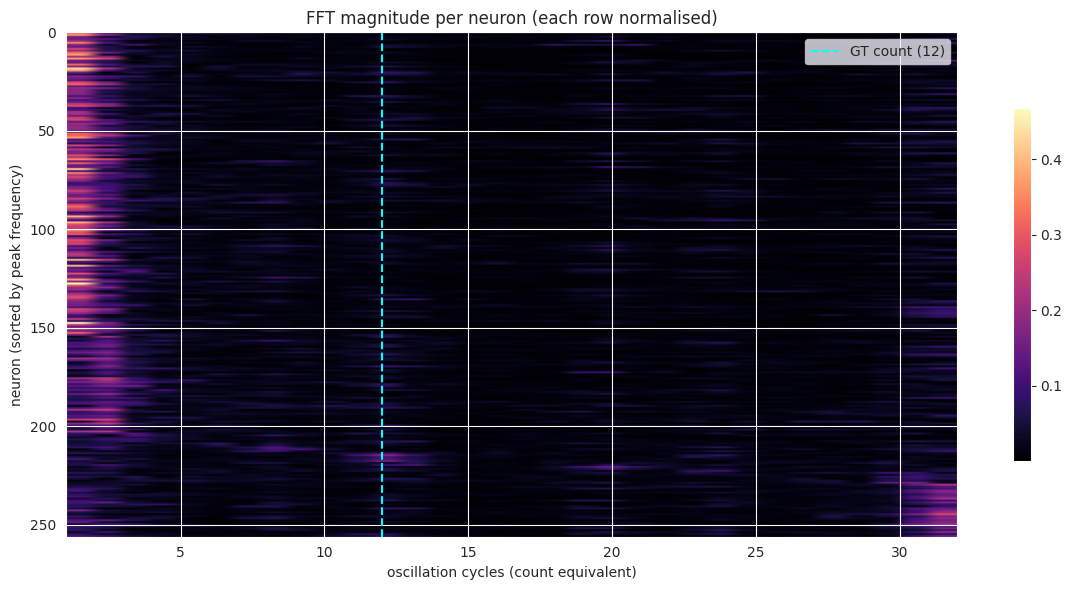

In [15]:
fft_all = np.abs(np.fft.rfft(post_acts, axis=0))   # (n_freqs, D)
fft_all = fft_all / (fft_all.sum(axis=0, keepdims=True) + 1e-9)  # normalise per neuron
neuron_order = fft_all[1:].argmax(axis=0).argsort()
fft_sorted = fft_all[:, neuron_order]

freqs = np.fft.rfftfreq(n_ticks)
cycle_counts_axis = freqs * n_ticks                 # x-axis in units of full oscillations

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(fft_sorted[1:].T, aspect='auto', cmap='magma',
               extent=[cycle_counts_axis[1], cycle_counts_axis[-1],
                       fft_sorted.shape[1], 0])
ax.axvline(gt_count, color='cyan', lw=1.5, ls='--', label=f'GT count ({gt_count})')
ax.set_xlabel('oscillation cycles (count equivalent)')
ax.set_ylabel('neuron (sorted by peak frequency)')
ax.set_title('FFT magnitude per neuron (each row normalised)')
ax.legend()
plt.colorbar(im, ax=ax, shrink=0.7); fig.tight_layout(); plt.show()

## 8. FFT-based count decoder

**The core interpretability experiment.** Each neuron's activation trace is
treated as a signal; its dominant FFT frequency (in oscillation-count units)
is its "vote" for the repetition count. Votes are aggregated via an
amplitude-weighted average. If the CTM's IIR synchronisation mechanism truly
acts as a phase-locked loop, this unsupervised FFT-decoded count should match
the ground-truth count — without any explicit frequency supervision.

GT count                        : 12
Model argmax (MC tick)          : 12
Model expected (MC tick)        : 12.00
FFT-decoded count (unsupervised): 3.67
OBO match — model   : True
OBO match — FFT     : False


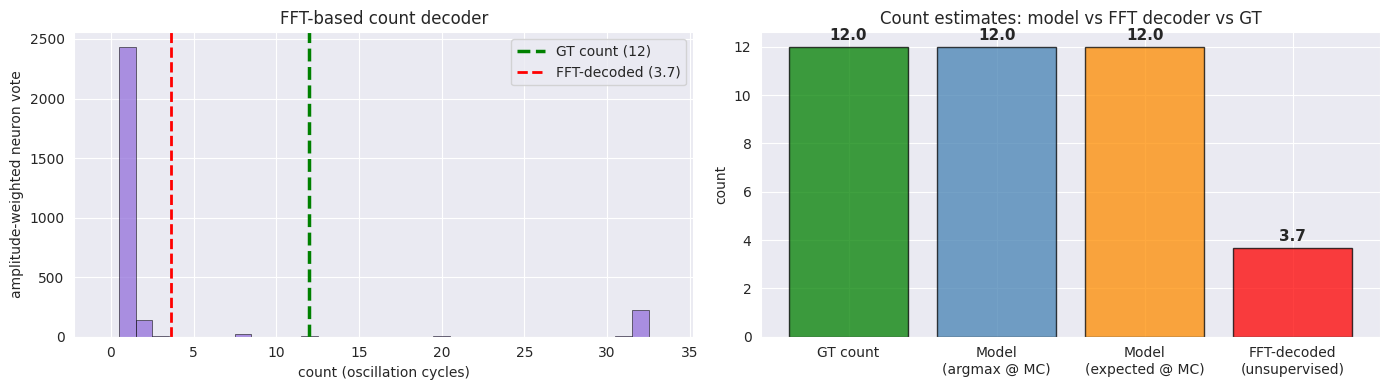

In [16]:
# Recompute raw (unnormalised) FFT magnitude for weighting.
fft_raw = np.abs(np.fft.rfft(post_acts, axis=0))   # (n_freqs, D)
freqs = np.fft.rfftfreq(n_ticks)
cycle_counts = freqs * n_ticks                      # in [0, n_ticks/2]

# Per-neuron dominant frequency excluding DC.
weights = fft_raw[1:].max(axis=0)                   # amplitude-based weight, (D,)
dominant_bin = fft_raw[1:].argmax(axis=0)           # (D,)
dominant_cycles = cycle_counts[1:][dominant_bin]    # (D,) votes in count units

predicted_count_fft = float(np.average(dominant_cycles, weights=weights))

print(f'GT count                        : {gt_count}')
print(f'Model argmax (MC tick)          : {mc_argmax}')
print(f'Model expected (MC tick)        : {mc_expected:.2f}')
print(f'FFT-decoded count (unsupervised): {predicted_count_fft:.2f}')
print(f'OBO match — model   : {abs(mc_argmax - gt_count) <= 1}')
print(f'OBO match — FFT     : {abs(predicted_count_fft - gt_count) <= 1}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: amplitude-weighted histogram of per-neuron dominant frequencies.
ax = axes[0]
max_cycle = int(cycle_counts.max()) + 1
bins = np.arange(0, max_cycle + 1.5) - 0.5
ax.hist(dominant_cycles, bins=bins, weights=weights,
        color='mediumpurple', alpha=0.75, edgecolor='k', lw=0.5)
ax.axvline(gt_count, color='green', ls='--', lw=2.5,
           label=f'GT count ({gt_count})')
ax.axvline(predicted_count_fft, color='red', ls='--', lw=2,
           label=f'FFT-decoded ({predicted_count_fft:.1f})')
ax.set_xlabel('count (oscillation cycles)')
ax.set_ylabel('amplitude-weighted neuron vote')
ax.set_title('FFT-based count decoder')
ax.legend()

# Right: side-by-side comparison bar chart.
ax = axes[1]
labels = ['GT count', 'Model\n(argmax @ MC)', 'Model\n(expected @ MC)', 'FFT-decoded\n(unsupervised)']
values = [gt_count, mc_argmax, mc_expected, predicted_count_fft]
colors = ['green', 'steelblue', 'darkorange', 'red']
bars = ax.bar(labels, values, color=colors, alpha=0.75, edgecolor='k')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15, f'{val:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('count')
ax.set_title('Count estimates: model vs FFT decoder vs GT')

fig.tight_layout(); plt.show()

## 9. Synchronisation magnitude over time

RMS of the action-sync and output-sync vectors per tick. The leaky
accumulators grow as evidence integrates over frames; the shape of this
curve reflects the learned time constants `r = exp(-decay_param)`.

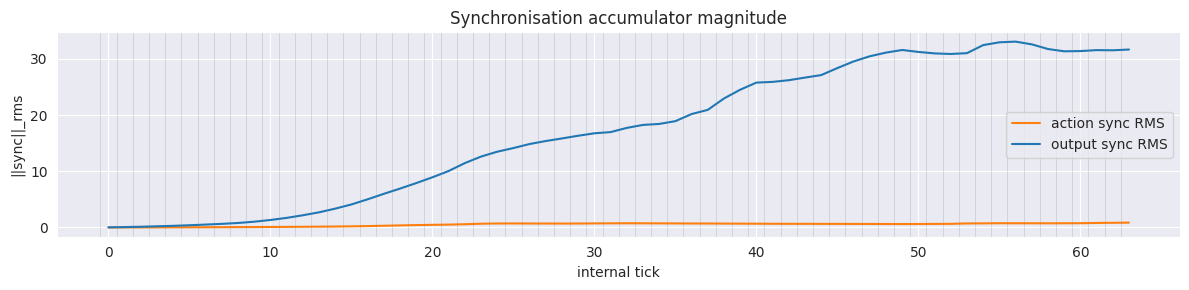

In [17]:
sa = np.sqrt((synch_action_track[:, 0] ** 2).mean(axis=-1))
so = np.sqrt((synch_out_track[:, 0]   ** 2).mean(axis=-1))
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(sa, label='action sync RMS', color='tab:orange')
ax.plot(so, label='output sync RMS', color='tab:blue')
for b in range(0, n_ticks, args.iterations_per_frame):
    ax.axvline(b - 0.5, color='grey', lw=0.4, alpha=0.4)
ax.set_xlabel('internal tick'); ax.set_ylabel('||sync||_rms')
ax.set_title('Synchronisation accumulator magnitude')
ax.legend(); fig.tight_layout(); plt.show()